# Compare Microlens Modeling Packages for Binary Lenses

This notebook compares the microlens models produced by the following modeling packages:

<li> BAGLE v1.0 </li>
<li> pyLIMA v1.9.8</li>
<li> VBMicrolensing v5.3.3</li>
<li> MuLensModel v3.3.1</li>

We will compare binary-lens models. This notebook was developed using the version numbers listed above.

In [32]:
import bagle
import MulensModel
import pyLIMA
from bagle import model
from pyLIMA import telescopes
from pyLIMA import event
from pyLIMA.models import generate_model
from pyLIMA import toolbox as microltoolbox
from bagle import frame_convert
import numpy as np
import pylab as plt

from astropy.coordinates import SkyCoord, GCRS, FK5
from astropy import units

print('** Versions **')
print('BAGLE     = ', bagle.__version__)
print('pyLIMA    = ', pyLIMA.__version__)
print('MulensMod = ', MulensModel.__version__)
!pip show VBMicrolensing

plt.rc('text', usetex=True)
%load_ext autoreload
%autoreload 2
%matplotlib inline

** Versions **
BAGLE     =  1.0.dev0
pyLIMA    =  1.9.8
MulensMod =  3.3.1
Name: VBMicrolensing
Version: 5.3.3
Summary: VBMicrolensing is a tool for efficient computation in gravitational microlensing events using the advanced contour integration method, supporting single, binary and multiple lenses.
Home-page: 
Author: 
Author-email: Valerio Bozza <valboz@sa.infn.it>, Vito Saggese <vitosaggese.vs@gmail.com>
License: LGPL-3.0
Location: /Users/jlu/.local/lib/python3.11/site-packages
Requires: numpy, pytest
Required-by: pyLIMA
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Color Map Function (Ignore)

In [33]:
def cmap_discrete_samp(n):
    """
    Return list of colors.
    """
    import matplotlib as mpl

    cmap = mpl.colormaps['tab10']

    # Take colors at regular intervals spanning the colormap.
    #colors = cmap(np.linspace(0.1, 0.85, n))
    #colors = cmap(np.linspace(0, 1, n))
    colors = cmap(np.linspace(0, 1, 10))
    colors[0] = plt.cm.colors.to_rgba('darkviolet')
    colors[2] = plt.cm.colors.to_rgba('limegreen')

    return colors

# Photometry-Only, Point-Source Binary-Lens Models With Parallax

Setup BAGLE parameters, which are all in Solar System Barycentric coordinates. Note, these models do have parallax.

In [34]:
c = SkyCoord('17:49:11.12 -21:10:19.9', unit=(units.hourangle, units.deg))
ra_bagle =  float(c.ra.value)
dec_bagle = float(c.dec.value)
t0_bagle = 60478.49
u0_amp_bagle = 1
t0_par_bagle = t0_bagle
tE_bagle = 100.4
mag_src_bagle = 17.675
b_sff_bagle = 0.5
q_bagle = 0.3
sep_bagle = .8
phi_bagle = 125
#piEE= .5
#piEN = .5
thetaE_bagle = 1#mas
piS_bagle = 0.1
xS0_E_bagle = 0
xS0_N_bagle = 0
muS_E_bagle = 0
muS_N_bagle = 0
piEE_bagle = 0.926
piEN_bagle = 0.932


Define time arrays for plotting the models

In [35]:
time_mjd = np.arange(t0_bagle - 6 * tE_bagle, t0_bagle + 6 * tE_bagle)
time_jd = time_mjd + 2400000.5


### Setup the BAGLE Model

Get the BAGLE model instance and the resulting amplification.

In [36]:
bagle_mod = model.PSBL_Phot_Par_Param1(t0_bagle, u0_amp_bagle, tE_bagle, piEE_bagle, piEN_bagle, q_bagle, sep_bagle, phi_bagle,
                                        [b_sff_bagle], [mag_src_bagle], raL = ra_bagle, decL = dec_bagle, root_tol=1e-6)

#BAGLE amplification
amp_bagle = bagle_mod.get_amplification(time_mjd)

### Conversions between reference frames

Convert microlensing quantities from SSB to the geoprojected frame of reference.

In [37]:
t0_geo, u0_geo, tE_geo, piEE_geo, piEN_geo = frame_convert.convert_helio_geo_phot(ra_bagle, dec_bagle, t0_bagle, bagle_mod.u0_amp, bagle_mod.tE,
                                               bagle_mod.piE[0], bagle_mod.piE[1], t0_par_bagle,
                                               murel_in='SL', murel_out='LS',
                                               coord_in='EN', coord_out='tb',
                                               plot=False)


In [38]:
t0_geo, u0_geo, tE_geo, piEE_geo, piEN_geo

(60462.1073106633,
 0.8868291186194835,
 33.33714575247199,
 -1.2813321390236478,
 -0.2903238700229156)

Now, modify quantities to move from the geometric center of the lens (BAGLE) to the center of mass of the lens system (other packages)

Refer to the Binary Paper Appendix for these equations

In [39]:
phi_piE = np.rad2deg(np.arctan2(piEN_bagle, piEE_bagle))  # PA of muRel on the sky
alpha = phi_piE + phi_bagle # PA of binary on the sky
q_pylima = q_bagle
q_prime = (1.0 - q_bagle) / (2.0 * (1 + q_bagle)) #Interim step for coordinate conversion

tE_pylima = tE_geo # days
piEE_pylima = piEE_geo
piEN_pylima = piEN_geo
alpha_in = -phi_bagle 

phi_rad = np.deg2rad(-phi_bagle)
murel_in = np.rad2deg(np.arctan2(piEN_bagle, piEE_bagle))
murel_out = np.rad2deg(np.arctan2(piEN_pylima, piEE_pylima))
delta_alpha = murel_out - murel_in + 180
alpha_out = alpha_in - delta_alpha
alpha_rad = np.deg2rad(alpha_out)

t0_pylima = t0_geo + q_prime * sep_bagle * tE_geo * np.cos(alpha_rad) + 2400000.5
u0_pylima = u0_geo + q_prime * sep_bagle * np.sin(alpha_rad)

t0_par_pylima = t0_par_bagle + 2400000.5
sep_pylima = sep_bagle

In [40]:
t0_pylima-2400000.5, u0_pylima

(60461.78390891105, 0.6716630798301018)

### Setup the PyLima Model

In [41]:
pylima_data = np.zeros((len(time_jd), 3), dtype=float)
pylima_data[:, 0] = time_jd
pylima_data[:, 1] = np.ones(len(time_jd)) * 1
pylima_data[:, 2] = np.ones(len(time_jd)) * 0.01
#Fake telescope
pylima_tel = telescopes.Telescope(name='OGLE', camera_filter='I',
                                  lightcurve=pylima_data,
                                  lightcurve_names = ['time', 'mag', 'err_mag'],
                                  lightcurve_units = ['JD', 'mag', 'mag'])

pylima_ev = event.Event()
pylima_ev.name = 'Fubar'
pylima_ev.telescopes.append(pylima_tel)
pylima_ev.ra = ra_bagle
pylima_ev.dec = dec_bagle

#Generates a pyLIMA PSBL model with full parallax
pylima_mod = generate_model.create_model('PSBL', pylima_ev, parallax=['Full', t0_par_pylima], fancy_parameters = None)

tmp_params = [t0_pylima, u0_pylima, tE_pylima, (sep_pylima), (q_pylima), alpha_rad, piEN_pylima, piEE_pylima]
pylima_mod.define_model_parameters()
pylima_mod.blend_flux_ratio = False

#Use tmp_params to compute pyLIMA params
pylima_par = pylima_mod.compute_pyLIMA_parameters(tmp_params)
pylima_par.fsource_OGLE = microltoolbox.brightness_transformation.magnitude_to_flux(mag_src_bagle)
pylima_par.fblend_OGLE = pylima_par.fsource_OGLE * (1.0 - b_sff_bagle) / b_sff_bagle

#pyLIMA amplification
amp_pylima = pylima_mod.model_magnification(pylima_tel, pylima_par)



### Setup the MulensModel model

In [45]:
params = {}
params['t_0'] =  t0_pylima
params['t_0_par'] = t0_par_pylima
params['u_0']= u0_pylima
params['t_E'] = tE_pylima
params['pi_E_N'] =  piEN_pylima
params['pi_E_E'] = piEE_pylima
params['q'] = q_bagle #MuLens mass ratio is the inverse of BAGLE
params['s'] =  sep_bagle
params['alpha']= alpha_out

MuModel = MulensModel.Model(params, coords=c)

# MuLens amplification
amp_mulens = MuModel.get_magnification(time_jd)


### Setup the VBM model


In [50]:
VBM = VBMicrolensing.VBMicrolensing()
VBM.RelTol = 1e-03
VBM.SetObjectCoordinates("17:49:11.12 -21:10:19.9")
VBM.parallaxsystem = 1
VBM.t0_par_fixed = 1 
VBM.t0_par = t0_par_pylima - 2450000.5 #HJD'


sep_vbm = sep_bagle
q_vbm = q_bagle
t0_vbm = t0_pylima - 2450000.5 #HJD'
u0_vbm = u0_pylima
alpha_vbm = alpha_rad
tE_vbm = tE_pylima
rho_vbm = 1e-18 #This is the source radius. Set incredibly small to match PSBL.
piEE_vbm = piEE_pylima
piEN_vbm = piEN_pylima

params = [np.log(sep_vbm), np.log(q_vbm), u0_vbm, alpha_vbm, np.log(rho_vbm), np.log(tE_vbm), t0_vbm, piEN_vbm, piEE_vbm]

#VBM amplification
amp_vbmicr = VBM.BinaryLightCurveParallax(params, time_mjd - 50000)[0]


### Plot

Text(0.5, 0, 'Time (MJD)')

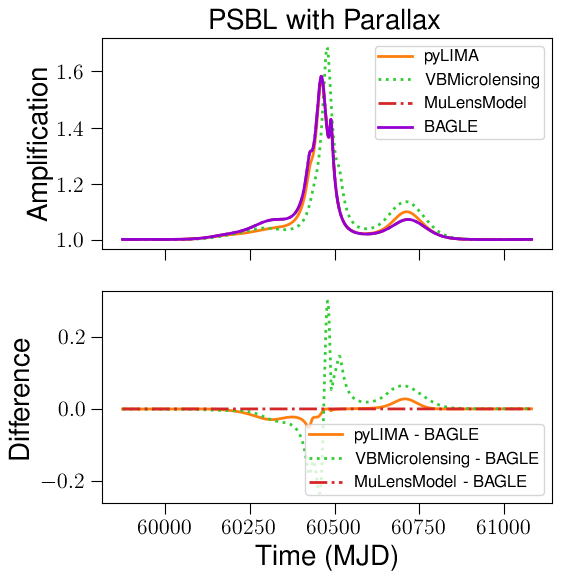

In [52]:
plt.rcParams.update({'font.size':20})
colors =cmap_discrete_samp(4)

fig, ax = plt.subplots(2, 1, figsize=(10,8), sharex=True, num=5)


def cmap_discrete_samp(n):
    """
    Return list of colors.
    """
    import matplotlib as mpl

    cmap = mpl.colormaps['tab10']

    # Take colors at regular intervals spanning the colormap.
    #colors = cmap(np.linspace(0.1, 0.85, n))
    #colors = cmap(np.linspace(0, 1, n))
    colors = cmap(np.linspace(0, 1, 10))
    colors[0] = plt.cm.colors.to_rgba('darkviolet')
    colors[2] = plt.cm.colors.to_rgba('limegreen')

    return colors


colors = cmap_discrete_samp(10)

plt.close(5)
fig, ax = plt.subplots(2, 1, sharex=True, num=5)
ax[0].plot(time_mjd, amp_pylima, label='pyLIMA', color=colors[1], ls='-', lw=2, marker='None')
ax[0].plot(time_mjd, amp_vbmicr, label='VBMicrolensing', color=colors[2], ls=':', lw=2, marker='None')
ax[0].plot(time_mjd, amp_mulens, label='MuLensModel', color=colors[3], ls='-.', lw=2, marker='None')
ax[0].plot(time_mjd, amp_bagle, label='BAGLE', color=colors[0], ls='-', lw=2, marker='None')

ax[0].set_ylabel('Amplification')
ax[0].legend(loc='upper right', fontsize=12)
ax[0].set_title('PSBL with Parallax')

ax[1].plot(time_mjd, amp_pylima - amp_bagle, color=colors[1], label='pyLIMA - BAGLE', ls='-', lw=2, marker='None')
ax[1].plot(time_mjd, amp_vbmicr - amp_bagle, color=colors[2], label='VBMicrolensing - BAGLE', ls=':', lw=2, marker='None')
ax[1].plot(time_mjd, amp_mulens - amp_bagle, color=colors[3], label='MuLensModel - BAGLE', ls='-.', lw=2, marker='None')
ax[1].legend(loc='lower right', fontsize=12)
ax[1].set_ylabel('Difference')
ax[1].set_xlabel('Time (MJD)')

